Epoch 1: Train Acc=91.63%, Test Acc=98.32%
Epoch 2: Train Acc=97.10%, Test Acc=98.82%
Epoch 3: Train Acc=97.79%, Test Acc=98.85%
Epoch 4: Train Acc=98.20%, Test Acc=98.98%
Epoch 5: Train Acc=98.50%, Test Acc=99.15%
Epoch 6: Train Acc=98.66%, Test Acc=99.13%
Epoch 7: Train Acc=98.87%, Test Acc=99.19%
Epoch 8: Train Acc=98.98%, Test Acc=99.29%
Epoch 9: Train Acc=99.01%, Test Acc=99.21%
Epoch 10: Train Acc=99.19%, Test Acc=99.31%


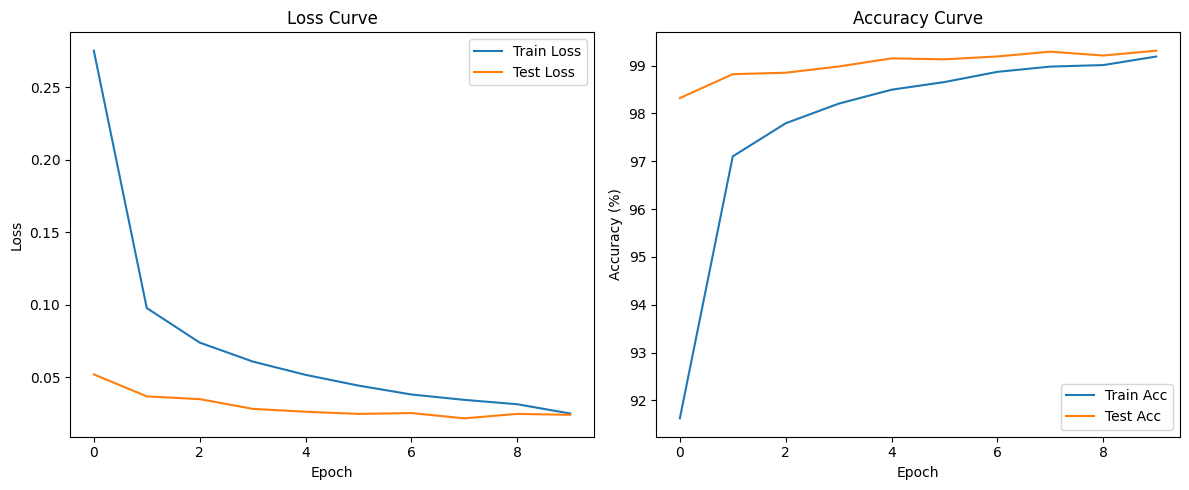

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load MNIST dataset
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)  # logits
    
def train(model, device, train_loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0, 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / len(train_loader), 100. * correct / total

def evaluate(model, device, test_loader, criterion):
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            test_loss += criterion(outputs, labels).item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
    return test_loss / len(test_loader), 100. * correct / len(test_loader.dataset)

#Model and Training

model = BaselineCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

for epoch in range(10):
    train_loss, train_acc = train(model, device, train_loader, optimizer, criterion)
    test_loss, test_acc = evaluate(model, device, test_loader, criterion)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    print(f"Epoch {epoch+1}: Train Acc={train_acc:.2f}%, Test Acc={test_acc:.2f}%")

#Plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch"), plt.ylabel("Loss"), plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Acc")
plt.plot(test_accuracies, label="Test Acc")
plt.xlabel("Epoch"), plt.ylabel("Accuracy (%)"), plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

class NoActivationCNN(nn.Module):
    def __init__(self):
        super(NoActivationCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(self.conv1(x))   # no ReLU
        x = self.pool(self.conv2(x))   # no ReLU
        x = x.view(-1, 64 * 7 * 7)
        x = self.fc1(x)                # no activation
        x = self.dropout(x)
        return self.fc2(x)

Epoch 1: Train Acc=94.58%, Test Acc=98.08%
Epoch 2: Train Acc=97.48%, Test Acc=98.61%
Epoch 3: Train Acc=98.10%, Test Acc=98.45%
Epoch 4: Train Acc=98.22%, Test Acc=98.35%
Epoch 5: Train Acc=98.37%, Test Acc=98.68%
Epoch 6: Train Acc=98.60%, Test Acc=98.51%
Epoch 7: Train Acc=98.74%, Test Acc=98.26%
Epoch 8: Train Acc=98.81%, Test Acc=98.46%
Epoch 9: Train Acc=98.90%, Test Acc=98.53%
Epoch 10: Train Acc=98.99%, Test Acc=98.70%


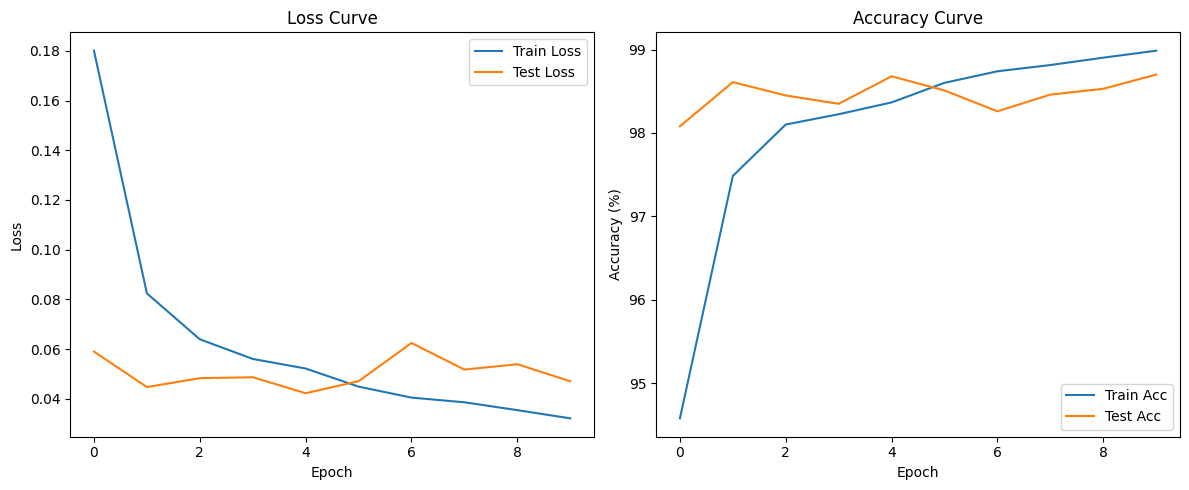

In [ ]:
class NoActivationCNN(nn.Module):
    def __init__(self):
        super(NoActivationCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(self.conv1(x))   # no ReLU
        x = self.pool(self.conv2(x))   # no ReLU
        x = x.view(-1, 64 * 7 * 7)
        x = self.fc1(x)                # no activation
        x = self.dropout(x)
        return self.fc2(x)
    
    #Model and Training

model = NoActivationCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

for epoch in range(10):
    train_loss, train_acc = train(model, device, train_loader, optimizer, criterion)
    test_loss, test_acc = evaluate(model, device, test_loader, criterion)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    print(f"Epoch {epoch+1}: Train Acc={train_acc:.2f}%, Test Acc={test_acc:.2f}%")

#Plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch"), plt.ylabel("Loss"), plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Acc")
plt.plot(test_accuracies, label="Test Acc")
plt.xlabel("Epoch"), plt.ylabel("Accuracy (%)"), plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

Firstly I tried to implement a model without ReLu withput linearity I expected poor results. Yes its not the best but it got there.

Epoch 1: Train Acc=55.91%, Test Acc=97.08%
Epoch 2: Train Acc=68.07%, Test Acc=97.78%
Epoch 3: Train Acc=71.01%, Test Acc=98.27%
Epoch 4: Train Acc=73.22%, Test Acc=98.47%
Epoch 5: Train Acc=75.52%, Test Acc=98.70%
Epoch 6: Train Acc=76.47%, Test Acc=98.79%
Epoch 7: Train Acc=77.62%, Test Acc=98.82%
Epoch 8: Train Acc=78.98%, Test Acc=98.86%
Epoch 9: Train Acc=79.98%, Test Acc=98.69%
Epoch 10: Train Acc=80.56%, Test Acc=98.77%


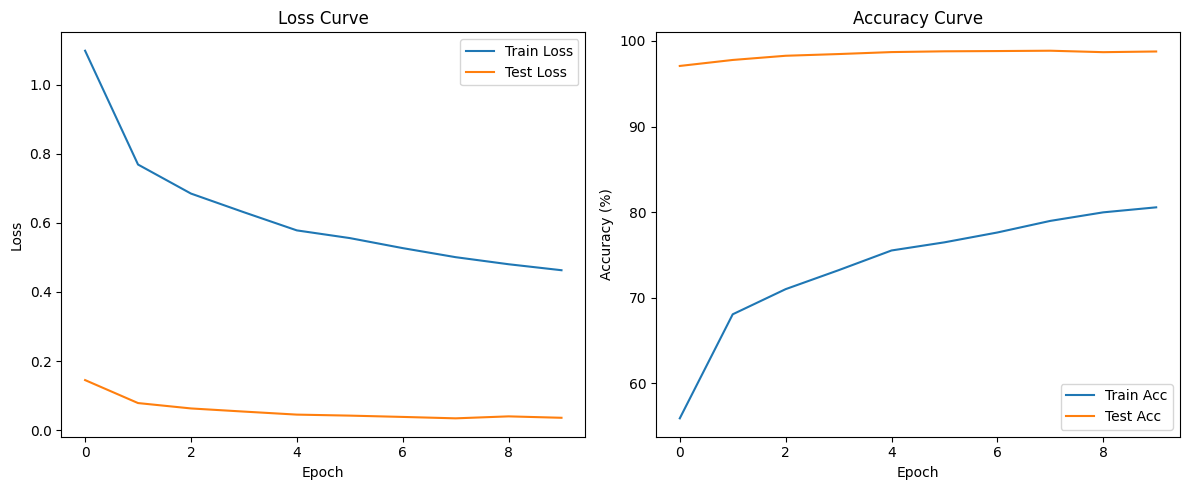

In [ ]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.dropout = nn.Dropout(0.9)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)  # logits
    
def train(model, device, train_loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0, 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / len(train_loader), 100. * correct / total

def evaluate(model, device, test_loader, criterion):
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            test_loss += criterion(outputs, labels).item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
    return test_loss / len(test_loader), 100. * correct / len(test_loader.dataset)

#Model and Training

model = BaselineCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

for epoch in range(10):
    train_loss, train_acc = train(model, device, train_loader, optimizer, criterion)
    test_loss, test_acc = evaluate(model, device, test_loader, criterion)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    print(f"Epoch {epoch+1}: Train Acc={train_acc:.2f}%, Test Acc={test_acc:.2f}%")

#Plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch"), plt.ylabel("Loss"), plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Acc")
plt.plot(test_accuracies, label="Test Acc")
plt.xlabel("Epoch"), plt.ylabel("Accuracy (%)"), plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

For second time I made dropout too high so too much info was lost in training so train accuracy plummeted.

Epoch 1: Train Acc=10.18%, Test Acc=8.92%
Epoch 2: Train Acc=10.22%, Test Acc=9.80%
Epoch 3: Train Acc=10.27%, Test Acc=11.35%
Epoch 4: Train Acc=10.12%, Test Acc=9.74%
Epoch 5: Train Acc=9.98%, Test Acc=11.35%
Epoch 6: Train Acc=10.28%, Test Acc=9.58%
Epoch 7: Train Acc=10.18%, Test Acc=9.58%
Epoch 8: Train Acc=10.12%, Test Acc=10.28%
Epoch 9: Train Acc=10.18%, Test Acc=10.10%
Epoch 10: Train Acc=10.03%, Test Acc=9.82%


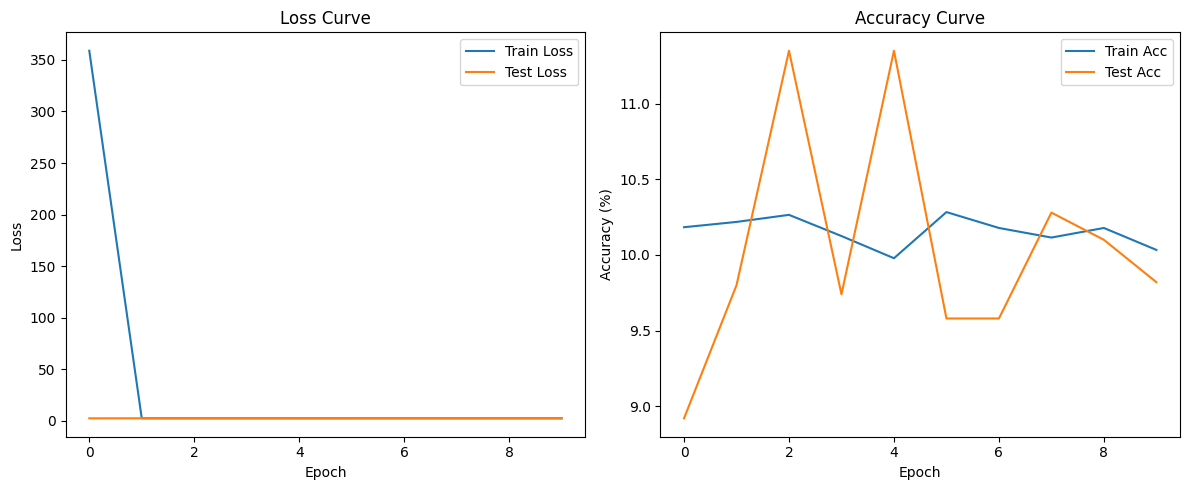

In [ ]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)  # logits
    
def train(model, device, train_loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0, 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / len(train_loader), 100. * correct / total

def evaluate(model, device, test_loader, criterion):
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            test_loss += criterion(outputs, labels).item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
    return test_loss / len(test_loader), 100. * correct / len(test_loader.dataset)

#Model and Training

model = BaselineCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.5)

train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

for epoch in range(10):
    train_loss, train_acc = train(model, device, train_loader, optimizer, criterion)
    test_loss, test_acc = evaluate(model, device, test_loader, criterion)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    print(f"Epoch {epoch+1}: Train Acc={train_acc:.2f}%, Test Acc={test_acc:.2f}%")

#Plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch"), plt.ylabel("Loss"), plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Acc")
plt.plot(test_accuracies, label="Test Acc")
plt.xlabel("Epoch"), plt.ylabel("Accuracy (%)"), plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

For my third attempt I increased learning rate to outrageous amounts. It caused it to be instable dur to increasing losses. This one definitely is broken.